In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator, NullFormatter
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 7,
        "figure.dpi": 200,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",
    }
)

In [2]:
import json
import subprocess
import textwrap


def run_r_fisher_test(a, b, c, d, alternative="two.sided", conf_level=0.95):
    """
    Run R's fisher.test() on a 2x2 table and return parsed results.

    Parameters
    ----------
    a, b, c, d : int
        2x2 contingency table values:
            [[a, b],
             [c, d]]
    alternative : {"two.sided", "greater", "less"}
        Alternative hypothesis for fisher.test().
    conf_level : float
        Confidence level for the odds ratio CI.

    Returns
    -------
    dict
        {
            "p_value": float,
            "odds_ratio": float,
            "ci_low": float,
            "ci_high": float,
            "alternative": str,
            "conf_level": float,
            "table": [[a, b], [c, d]]
        }
    """
    valid_alternatives = {"two.sided", "greater", "less"}
    if alternative not in valid_alternatives:
        raise ValueError(f"alternative must be one of {valid_alternatives}")
    if not (0 < conf_level < 1):
        raise ValueError("conf_level must be between 0 and 1")

    # force integers
    a, b, c, d = map(int, (a, b, c, d))

    r_code = textwrap.dedent(
        f"""
        options(warn = 1)

        tab <- matrix(c({a}, {b}, {c}, {d}), nrow = 2, byrow = TRUE)
        res <- fisher.test(
            tab,
            alternative = "{alternative}",
            conf.int = TRUE,
            conf.level = {conf_level}
        )

        out <- list(
            p_value = unname(res$p.value),
            odds_ratio = unname(res$estimate),
            ci_low = unname(res$conf.int[1]),
            ci_high = unname(res$conf.int[2]),
            alternative = "{alternative}",
            conf_level = {conf_level}
        )

        cat(jsonlite::toJSON(out, auto_unbox = TRUE, digits = NA))
    """
    )

    try:
        result = subprocess.run(
            ["Rscript", "-e", r_code], capture_output=True, text=True, check=True
        )
    except FileNotFoundError:
        raise RuntimeError(
            "Rscript not found. Please make sure R is installed and Rscript is in PATH."
        )
    except subprocess.CalledProcessError as e:
        raise RuntimeError(
            f"R fisher.test failed.\nSTDOUT:\n{e.stdout}\nSTDERR:\n{e.stderr}"
        ) from e

    try:
        parsed = json.loads(result.stdout)
    except json.JSONDecodeError as e:
        raise RuntimeError(
            f"Failed to parse R output as JSON.\nRaw output:\n{result.stdout}\nSTDERR:\n{result.stderr}"
        ) from e

    parsed["table"] = [[a, b], [c, d]]
    return parsed

In [3]:
def perform_enrichment_test(
    df: pd.DataFrame,
    mut_label: str,
    alternative="two.sided",
):

    case_mis = df[f"case.mis{mut_label}"].sum()
    case_syn = df[f"case.syn"].sum()
    control_mis = df[f"control.mis{mut_label}"].sum()
    control_syn = df[f"control.syn"].sum()

    return run_r_fisher_test(
        case_mis, case_syn, control_mis, control_syn, alternative=alternative
    )

In [4]:
# Load ASD-related genes
ASD_related_gene = [line.strip() for line in open("data/ASD-related_gene.lst", "r")]

In [5]:
# Read data (supplementary table from https://www.nature.com/articles/s41588-022-01104-0)
def read_data(filepath):

    data = pd.read_csv(filepath, sep="\t")

    data_RDH = data[data["gene"].str.startswith("HIST")]
    data_RDH = data_RDH[data_RDH["gene"].str.contains("H1") == False]

    data["is_cRDH"] = False
    data.loc[data.index.isin(data_RDH.index), "is_cRDH"] = True

    data["is_ASD"] = False
    data.loc[data["gene"].isin(ASD_related_gene), "is_ASD"] = True

    data["is_OG"] = True
    data.loc[data["is_cRDH"] | data["is_ASD"], "is_OG"] = False

    for sample in ["case", "control"]:
        data[f"{sample}.mis.all"] = (
            data[f"{sample}.misb"] + data[f"{sample}.misa"] + data[f"{sample}.mis"]
        )
        data[f"{sample}.mis.a+b"] = data[f"{sample}.misb"] + data[f"{sample}.misa"]

    return data


case_control_pergene_data = read_data(
    "data/Fu2022_Nature_autism_denovo_snv-indel.ST7.per-gene_case-control-count.csv"
)

In [6]:
plot_gene_types = ["ASD", "cRDH", "OG"]
df = pd.DataFrame(columns=["Gene", "Value", "P", "Mistype"])

for title, mut_label in zip(
    ["Mis MPC>2", "Mis 2>MPC>1", "Mis 1>MPC", "All Mis"], ["b", "a", "", ".all"]
):

    case_control_ratio = []
    results_lst = []

    for gene_type in plot_gene_types:

        results = perform_enrichment_test(
            case_control_pergene_data[case_control_pergene_data[f"is_{gene_type}"]],
            mut_label,
            alternative="two.sided",
        )

        df = df._append(
            {"Gene": gene_type, "Mistype": title, **results}, ignore_index=True
        )

df["Value"] = np.log2(df["Value"].astype(float))

(-0.5, 3.5)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


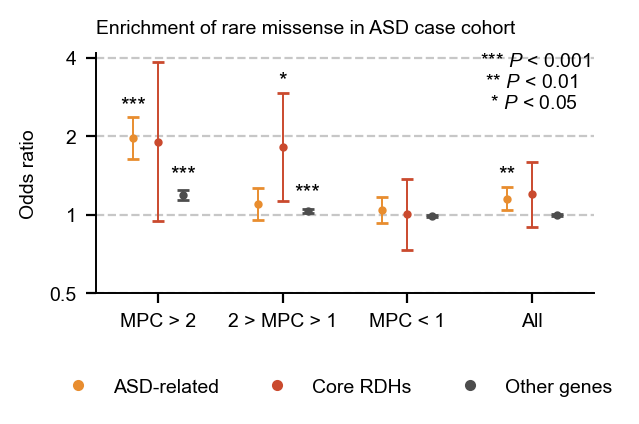

In [7]:
# Plot
mistype_order = ["Mis MPC>2", "Mis 2>MPC>1", "Mis 1>MPC", "All Mis"]
gene_colors = {
    "ASD": "#E88D2F",
    "cRDH": "#CA4A2E",
    "OG": "#4d4d4d",
}
hue_order = [g for g in gene_colors if g in df["Gene"].unique()]

plot_df = df.copy()
plot_df["Mistype"] = pd.Categorical(
    plot_df["Mistype"], categories=mistype_order, ordered=True
)
plot_df["Gene"] = pd.Categorical(plot_df["Gene"], categories=hue_order, ordered=True)
plot_df = plot_df.sort_values(["Mistype", "Gene"]).reset_index(drop=True)

or_mat = plot_df.pivot(index="Mistype", columns="Gene", values="odds_ratio").loc[
    mistype_order, hue_order
]
low_mat = plot_df.pivot(index="Mistype", columns="Gene", values="ci_low").loc[
    mistype_order, hue_order
]
high_mat = plot_df.pivot(index="Mistype", columns="Gene", values="ci_high").loc[
    mistype_order, hue_order
]
p_mat = plot_df.pivot(index="Mistype", columns="Gene", values="p_value").loc[
    mistype_order, hue_order
]

fig, ax = plt.subplots(figsize=(3, 1.6))

x = np.arange(len(mistype_order))
n_hue = len(hue_order)
group_width = 0.6
inner_gap = 0
bar_width = group_width / (n_hue + inner_gap * (n_hue - 1))


def get_significance(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""


for i, gene in enumerate(hue_order):
    xpos = (
        x - group_width / 2 + bar_width / 2 + i * bar_width + i * inner_gap * bar_width
    )
    y = or_mat[gene].to_numpy()
    yerr = np.vstack([y - low_mat[gene].to_numpy(), high_mat[gene].to_numpy() - y])

    ax.errorbar(
        xpos,
        y,
        yerr=yerr,
        fmt="o",
        color=gene_colors[gene],
        ecolor=gene_colors[gene],
        elinewidth=0.7,
        capsize=2,
        markersize=2,
        zorder=3,
    )

    offset = 0.02 * (
        ax.get_ylim()[1] - ax.get_ylim()[0]
        if ax.get_ylim()[1] > ax.get_ylim()[0]
        else 1
    )
    for xi, yi, hi, p in zip(
        xpos, y, high_mat[gene].to_numpy(), p_mat[gene].to_numpy()
    ):
        sig = get_significance(p)
        if sig:
            ax.text(xi, hi + offset, sig, ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["MPC > 2", "2 > MPC > 1", "MPC < 1", "All"])
ax.set_xlabel("")
ax.set_ylabel("Odds ratio")
ax.grid(True, axis="y", ls="--", alpha=0.7, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color=gene_colors[gene],
        markerfacecolor=gene_colors[gene],
        markeredgecolor=gene_colors[gene],
        markersize=3,
        label=gene,
    )
    for gene in gene_colors
]
labels = ["ASD-related", "Core RDHs", "Other genes"][: len(hue_order)]
ax.legend(
    handles,
    labels,
    bbox_to_anchor=(0.48, -0.5),
    loc="lower center",
    ncols=4,
    frameon=False,
)
ax.set_title("Enrichment of rare missense in ASD case cohort", pad=7, loc="left")
ax.text(
    s="*** $P$ < 0.001\n ** $P$ < 0.01\n  * $P$ < 0.05",
    x=0.77,
    y=1,
    transform=ax.transAxes,
    ha="left",
    va="top",
)
ax.set_yscale("log")
yticks = [0.5, 1, 2, 4]
ax.set_yticks(yticks)
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_yticklabels(f"{i}" for i in yticks)
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_xlim(-0.5, 3.5)